# 🚦 Movilidad urbana y productividad económica en Latinoamérica (2024)

**Autor:** Daniel Medina Guzmán · Analista de Datos Junior
**Proyecto:** Bootcamp de Análisis de Datos de TripleTen (Sprint 5)

## Objetivo

Evaluar cómo se relaciona la **movilidad urbana** (congestión, tiempos de viaje) con la **productividad económica** (PIB per cápita, desempleo) en ciudades latinoamericanas durante 2024. El escenario de negocio es simulado: un banco de desarrollo quiere decidir en qué ciudades conviene analizar inversiones en transporte. Los datos son reales:

- **TomTom Traffic Index:** mediciones periódicas de tráfico por ciudad.
- **OECD Cities:** PIB per cápita, desempleo, contaminación (PM2.5) y población.

## Estructura del notebook

| Parte | Contenido | ¿Necesita los archivos originales? |
| --- | --- | --- |
| **A. Preparación de datos** | Carga, limpieza, filtro de 2024, agregación por ciudad, unión y exportación | Sí (`tomtom_traffic.csv` y `oecd_city_economy.csv`, no incluidos por su tamaño). Las salidas ya están guardadas en el notebook |
| **B. Análisis exploratorio** | Distribuciones, relación tráfico–economía, correlaciones y conclusiones | No. Parte del dataset limpio en `data/processed/` y se puede ejecutar completa |

> **Nota:** en la plataforma del bootcamp los archivos originales se leían desde `/datasets/`. Aquí las rutas apuntan a `../data/raw/`.

---
# Parte A · Preparación de datos

## A.1 Carga de datos

In [4]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Archivos originales (no incluidos en el repositorio por su tamaño)
traffic = pd.read_csv('../data/raw/tomtom_traffic.csv')
eco = pd.read_csv('../data/raw/oecd_city_economy.csv')

In [6]:
traffic.head() # mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [7]:
eco.head() # mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


## A.2 Exploración de la estructura y los tipos de datos

In [8]:
traffic.info() 
traffic.head(3) # Examinar la estructura de traffic

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


**Tabla de tráfico (`traffic`):** 1,004,464 registros y 12 columnas, sin valores nulos.
- `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` están como texto (`object`) y deben convertirse a `datetime`.
- El resto de las métricas de tráfico ya son numéricas (`float64`).

In [9]:
eco.info() 
eco.head(3) # Examinar la estructura de eco

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


**Tabla económica (`eco`):** 30 registros y 7 columnas, sin valores nulos.
- `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` y `Population (M)` están como texto (`object`), con formatos como `15.782,00` (punto de miles y coma decimal), `6.2%` (símbolo de porcentaje) y `15,2` (coma decimal). Deben convertirse a `float`.

## A.3 Estandarización de nombres de columnas (`snake_case`)

In [10]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns = [
    'country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live', 
    'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago', 
    'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins', 
    'travel_time_historic_per_10kms_mins', 'mins_delay'
]
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [11]:
# Estandarizar los nombres de las columnas de eco
eco.columns = [ 
    'year', 'city', 'country', 'city_gdp_capita', 
    'unemployment_perc', 'pm25_ug_m3', 'population_m' 
]
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_perc',
       'pm25_ug_m3', 'population_m'],
      dtype='object')

## A.4 Corrección de formatos numéricos y de fecha

- Fechas de `traffic` a `datetime` (con `errors='coerce'` para no romper si hay valores inválidos).
- En `eco`: se eliminan separadores de miles y el símbolo `%`, se reemplaza la coma decimal por punto y se convierte a `float`.
- Se crea `population` (habitantes) multiplicando `population_m` (millones) por 1,000,000.

> `pm25_ug_m3` se conserva como texto en esta etapa porque no se usa en el análisis; se convierte en la Parte B.

In [12]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')
# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [13]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_perc'] = eco['unemployment_perc'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               30 non-null     int64  
 1   city               30 non-null     object 
 2   country            30 non-null     object 
 3   city_gdp_capita    30 non-null     float64
 4   unemployment_perc  30 non-null     float64
 5   pm25_ug_m3         30 non-null     object 
 6   population_m       30 non-null     float64
 7   population         30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_perc,pm25_ug_m3,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


## A.5 Extracción del año y filtro de 2024

In [14]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [15]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_perc,pm25_ug_m3,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


## A.6 Promedios de tráfico por ciudad

El dataset de tráfico tiene muchos registros por ciudad. Se agrupa por `city`, `country` y `year` y se calcula el promedio anual de cada métrica, para obtener **una fila por ciudad**.

In [16]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'], as_index=False)[[
    'jams_delay', 
    'traffic_index_live', 
    'jams_length_in_kms', 
    'jams_count', 
    'mins_delay', 
    'travel_time_live_per_10kms_mins', 
    'travel_time_historic_per_10kms_mins'
]].mean()
# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [17]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


**Observación:** en la muestra global de 387 ciudades, **Ciudad de México** tiene el mayor retraso promedio por congestión (`jams_delay` ≈ 2,833), seguida de Tokio, Nueva York, Londres y Manila.

## A.7 Unión de movilidad y economía

Se une con `pd.merge` de tipo **inner** por `city` y `year`, para conservar solo las ciudades que tienen información en ambas fuentes. El resultado son **15 ciudades latinoamericanas**.

In [18]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city', 'country', 'year', 'jams_delay', 'traffic_index_live', 
             'jams_length_in_kms', 'jams_count', 'mins_delay', 
             'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins']


right_cols = ['city', 'year', 'city_gdp_capita', 'unemployment_perc', 'pm25_ug_m3', 'population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'])

# Mostrar las primeras 5 filas
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_perc,pm25_ug_m3,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


## A.8 Exportación del dataset limpio

In [ ]:
import os

ruta_salida = '../data/processed/ladb_mobility_economy_2024_clean.csv'
merged.to_csv(ruta_salida, index=False)

# Verificación de la exportación
print(f'Archivo guardado: {ruta_salida}')
print(f'Tamaño: {os.path.getsize(ruta_salida)} bytes | Filas: {len(merged)} | Columnas: {merged.shape[1]}')

---
# Parte B · Análisis exploratorio

Esta parte se ejecuta desde el **dataset limpio** (`data/processed/ladb_mobility_economy_2024_clean.csv`), por lo que no necesita los archivos originales.

## B.1 Carga y variables derivadas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
Path('../images').mkdir(exist_ok=True)

df = pd.read_csv('../data/processed/ladb_mobility_economy_2024_clean.csv')

# pm25_ug_m3 quedó como texto con coma decimal: se convierte a número
df['pm25_ug_m3'] = df['pm25_ug_m3'].astype(str).str.replace(',', '.').astype(float)

# Nombre legible de la ciudad y retraso normalizado por población (minutos por millón de habitantes)
df['ciudad'] = df['city'].str.replace('-', ' ').str.title()
df['jams_delay_per_million'] = df['jams_delay'] / (df['population'] / 1e6)

print(f"Ciudades: {df['city'].nunique()} | Países: {df['country'].nunique()} | Año: {df['year'].unique()}")
print(df['country'].value_counts().to_string())

Ciudades: 15 | Países: 7 | Año: [2024]
country
BRA    9
COL    1
ARG    1
PER    1
MEX    1
URY    1
CHL    1


## B.2 Distribución de la congestión (`jams_delay`)

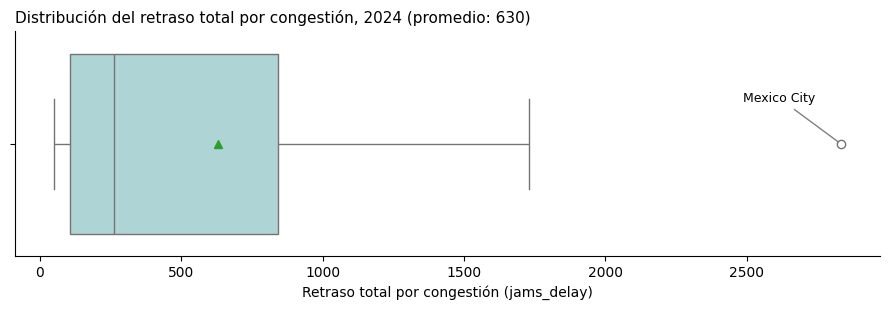

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.2))
sns.boxplot(data=df, x='jams_delay', showmeans=True, color='#a8dadc', ax=ax)
ax.set_title(f"Distribución del retraso total por congestión, 2024 (promedio: {df['jams_delay'].mean():.0f})", loc='left', fontsize=11)
ax.set_xlabel('Retraso total por congestión (jams_delay)')
top = df.loc[df['jams_delay'].idxmax()]
ax.annotate(top['ciudad'], (top['jams_delay'], 0), xytext=(-70, 30), textcoords='offset points',
            arrowprops=dict(arrowstyle='-', color='gray'), fontsize=9)
plt.tight_layout()
plt.savefig('../images/01_boxplot_jams_delay.png', dpi=150)
plt.show()

Ciudad de México es el valor atípico más marcado: su retraso total es muy superior al del resto de la muestra.

## B.3 Distribución del PIB per cápita

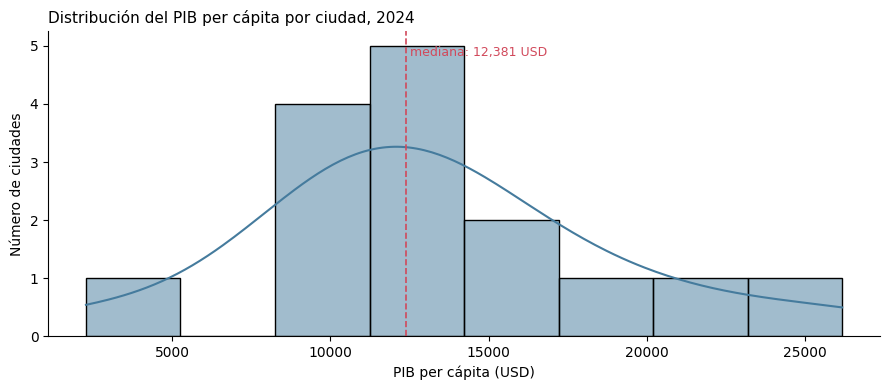

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='city_gdp_capita', bins=8, kde=True, color='#457b9d', ax=ax)
med = df['city_gdp_capita'].median()
ax.axvline(med, color='#d1495b', ls='--', lw=1.2)
ax.text(med, ax.get_ylim()[1]*0.92, f' mediana: {med:,.0f} USD', color='#d1495b', fontsize=9)
ax.set_title('Distribución del PIB per cápita por ciudad, 2024', loc='left', fontsize=11)
ax.set_xlabel('PIB per cápita (USD)'); ax.set_ylabel('Número de ciudades')
plt.tight_layout()
plt.savefig('../images/02_histograma_pib_per_capita.png', dpi=150)
plt.show()

La mayoría de las ciudades se concentra entre 8,000 y 18,000 USD por habitante. Montevideo (26,176 USD) y Ciudad de México (21,111 USD) están en el extremo alto y **Santiago (2,277 USD) es un dato atípico** muy por debajo del resto.

## B.4 Comparación por ciudad

La comparación original con un solo gráfico de barras mezclaba variables con escalas muy distintas (cientos frente a decenas de miles), lo que hacía casi invisibles las barras de tráfico. Se reemplaza por dos paneles alineados, cada uno con su propia escala.

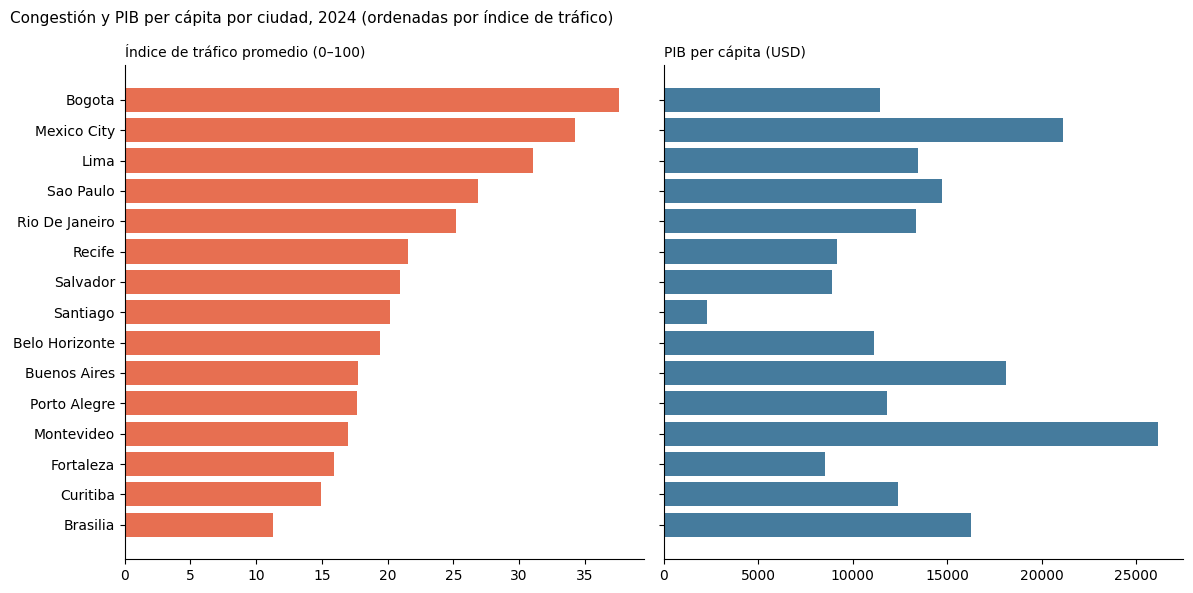

In [4]:
orden = df.sort_values('traffic_index_live')
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].barh(orden['ciudad'], orden['traffic_index_live'], color='#e76f51')
axes[0].set_title('Índice de tráfico promedio (0–100)', loc='left', fontsize=10)
axes[1].barh(orden['ciudad'], orden['city_gdp_capita'], color='#457b9d')
axes[1].set_title('PIB per cápita (USD)', loc='left', fontsize=10)
plt.suptitle('Congestión y PIB per cápita por ciudad, 2024 (ordenadas por índice de tráfico)', x=0.01, ha='left', fontsize=11)
plt.tight_layout()
plt.savefig('../images/05_comparativa_ciudades.png', dpi=150)
plt.show()

## B.5 Relación entre congestión y productividad

Cada punto es una ciudad; el tamaño representa la población y las líneas punteadas marcan las medianas.

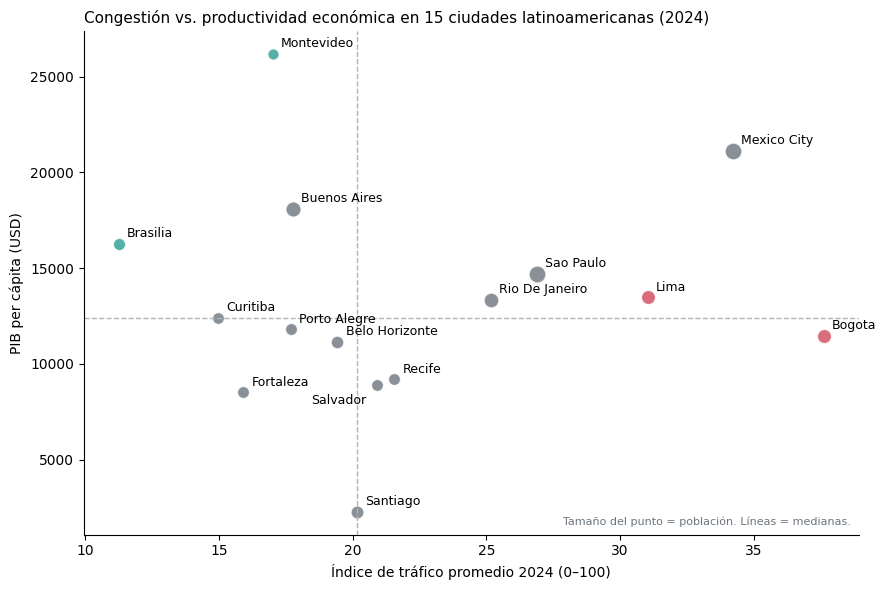

In [5]:
# Desplazamiento de etiquetas que se solaparían (Salvador y Recife tienen valores muy cercanos)
offsets = {'Salvador': (-8, -14, 'right')}

fig, ax = plt.subplots(figsize=(9, 6))
for _, r in df.iterrows():
    color = '#d1495b' if r['ciudad'] in ('Bogota', 'Lima') else ('#2a9d8f' if r['ciudad'] in ('Montevideo', 'Brasilia') else '#6c757d')
    ax.scatter(r['traffic_index_live'], r['city_gdp_capita'], s=60 + r['population'] / 2.5e5, color=color, alpha=.8, edgecolor='white')
    dx, dy, ha = offsets.get(r['ciudad'], (6, 5, 'left'))
    ax.annotate(r['ciudad'], (r['traffic_index_live'], r['city_gdp_capita']), xytext=(dx, dy), textcoords='offset points', fontsize=9, ha=ha)
ax.axvline(df['traffic_index_live'].median(), color='#adb5bd', ls='--', lw=1)
ax.axhline(df['city_gdp_capita'].median(), color='#adb5bd', ls='--', lw=1)
ax.set_xlabel('Índice de tráfico promedio 2024 (0–100)'); ax.set_ylabel('PIB per cápita (USD)')
ax.set_title('Congestión vs. productividad económica en 15 ciudades latinoamericanas (2024)', fontsize=11, loc='left')
ax.text(.99, .02, 'Tamaño del punto = población. Líneas = medianas.', transform=ax.transAxes, ha='right', fontsize=8, color='#6c757d')
plt.tight_layout()
plt.savefig('../images/03_dispersion_trafico_vs_pib.png', dpi=150)
plt.show()

### Ciudades según su posición respecto a las medianas

In [6]:
med_trafico = df['traffic_index_live'].median()
med_pib = df['city_gdp_capita'].median()

def cuadrante(r):
    alto_trafico = r['traffic_index_live'] > med_trafico
    alto_pib = r['city_gdp_capita'] > med_pib
    if alto_trafico and not alto_pib: return 'Congestión alta / PIB bajo'
    if alto_trafico and alto_pib:     return 'Congestión alta / PIB alto'
    if not alto_trafico and alto_pib: return 'Congestión baja / PIB alto'
    return 'Congestión baja / PIB bajo'

df['cuadrante'] = df.apply(cuadrante, axis=1)
(df.sort_values(['cuadrante', 'traffic_index_live'], ascending=[True, False])
   [['ciudad', 'cuadrante', 'traffic_index_live', 'city_gdp_capita']]
   .round({'traffic_index_live': 1}).to_string(index=False))

'        ciudad                  cuadrante  traffic_index_live  city_gdp_capita\n   Mexico City Congestión alta / PIB alto                34.2          21111.0\n          Lima Congestión alta / PIB alto                31.0          13472.0\n     Sao Paulo Congestión alta / PIB alto                26.9          14703.0\nRio De Janeiro Congestión alta / PIB alto                25.2          13349.0\n        Bogota Congestión alta / PIB bajo                37.6          11442.0\n        Recife Congestión alta / PIB bajo                21.6           9189.0\n      Salvador Congestión alta / PIB bajo                20.9           8899.0\n  Buenos Aires Congestión baja / PIB alto                17.8          18117.0\n    Montevideo Congestión baja / PIB alto                17.0          26176.0\n      Brasilia Congestión baja / PIB alto                11.3          16251.0\n      Santiago Congestión baja / PIB bajo                20.2           2277.0\nBelo Horizonte Congestión baja / PIB ba

**Lectura:** el cuadrante de *congestión alta / PIB bajo* incluye a Bogotá (con el índice de tráfico más alto de la muestra, 37.6), y también a Recife y Salvador, aunque estos dos quedan apenas por encima de la mediana de tráfico. Santiago está justo en la mediana de tráfico (20.2) y con un PIB atípico, por lo que el criterio de corte lo ubica en *congestión baja*; Curitiba coincide con la mediana del PIB. Lima, Ciudad de México, São Paulo y Río de Janeiro combinan congestión alta con PIB por encima de la mediana.

## B.6 Correlaciones con el PIB per cápita

Con solo 15 ciudades, las correlaciones son **orientativas**. Se reportan Pearson y Spearman (esta última es menos sensible a valores extremos) junto con su valor p.

In [7]:
variables = {
    'unemployment_perc': 'Desempleo (%)',
    'jams_delay': 'Retraso total por congestión',
    'mins_delay': 'Minutos de retraso por 10 km',
    'travel_time_live_per_10kms_mins': 'Tiempo de viaje por 10 km',
    'traffic_index_live': 'Índice de tráfico',
    'jams_delay_per_million': 'Retraso por millón de habitantes',
}

def tabla_correlaciones(datos):
    filas = []
    for col, nombre in variables.items():
        r, p = stats.pearsonr(datos[col], datos['city_gdp_capita'])
        rs, ps = stats.spearmanr(datos[col], datos['city_gdp_capita'])
        filas.append({'Variable': nombre, 'Pearson': r, 'p (Pearson)': p, 'Spearman': rs, 'p (Spearman)': ps})
    return pd.DataFrame(filas).round(2)

print(f'Todas las ciudades (n = {len(df)})')
tabla_correlaciones(df)

Todas las ciudades (n = 15)


,Variable,Pearson,p (Pearson),Spearman,p (Spearman)
0,Desempleo (%),-0.51,0.05,-0.65,0.01
1,Retraso total por congestión,0.28,0.31,0.21,0.46
2,Minutos de retraso por 10 km,0.24,0.39,0.39,0.16
3,Tiempo de viaje por 10 km,0.09,0.75,0.18,0.52
4,Índice de tráfico,0.06,0.84,0.01,0.96
5,Retraso por millón de habitantes,0.04,0.89,0.20,0.47


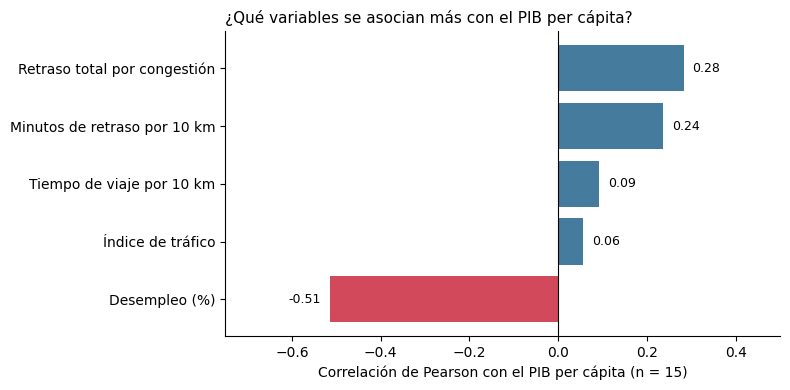

In [8]:
cor = pd.Series({nombre: df[col].corr(df['city_gdp_capita']) for col, nombre in variables.items() if col != 'jams_delay_per_million'}).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cor.index, cor.values, color=['#d1495b' if v < 0 else '#457b9d' for v in cor.values])
for i, v in enumerate(cor.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.axvline(0, color='black', lw=.8); ax.set_xlim(-0.75, 0.5)
ax.set_xlabel('Correlación de Pearson con el PIB per cápita (n = 15)')
ax.set_title('¿Qué variables se asocian más con el PIB per cápita?', fontsize=11, loc='left')
plt.tight_layout()
plt.savefig('../images/04_correlaciones_con_pib.png', dpi=150)
plt.show()

### Sensibilidad: sin Santiago (dato atípico)

Santiago tiene un PIB per cápita muy inferior al resto. Se repiten las correlaciones sin esa ciudad para comprobar si las conclusiones dependen de ese dato.

In [9]:
print(f'Sin Santiago (n = {len(df) - 1})')
tabla_correlaciones(df[df['city'] != 'santiago'])

Sin Santiago (n = 14)


,Variable,Pearson,p (Pearson),Spearman,p (Spearman)
0,Desempleo (%),-0.68,0.01,-0.86,0.00
1,Retraso total por congestión,0.33,0.24,0.32,0.26
2,Minutos de retraso por 10 km,0.28,0.33,0.54,0.04
3,Tiempo de viaje por 10 km,0.00,1.00,0.07,0.81
4,Índice de tráfico,0.02,0.94,0.03,0.92
5,Retraso por millón de habitantes,0.23,0.43,0.36,0.20


## B.7 El retraso total depende del tamaño de la ciudad

`jams_delay` es un retraso **acumulado** en toda la red vial, por lo que crece con el tamaño de la ciudad. Se comprueba y se normaliza por población.

In [10]:
print(f"Correlación jams_delay vs. población: {df['jams_delay'].corr(df['population']):.2f}\n")
(df.sort_values('jams_delay_per_million', ascending=False)
   [['ciudad', 'jams_delay', 'jams_delay_per_million', 'city_gdp_capita']]
   .round(1).head(6).to_string(index=False))

Correlación jams_delay vs. población: 0.88



'     ciudad  jams_delay  jams_delay_per_million  city_gdp_capita\nMexico City      2833.1                   128.2          21111.0\n     Bogota      1141.6                   101.0          11442.0\n       Lima      1052.3                    94.0          13472.0\n   Santiago       629.9                    88.7           2277.0\n  Sao Paulo      1729.2                    76.5          14703.0\n   Curitiba       183.5                    49.6          12381.0'

El retraso total tiene una correlación de 0.88 con la población: mide en gran parte el **tamaño** de la ciudad. Al normalizar por millón de habitantes, Ciudad de México, Bogotá y Lima siguen encabezando el ranking, y la relación con el PIB per cápita prácticamente desaparece (r ≈ 0.04).

---
# Conclusiones

## Resumen ejecutivo

**Pregunta central.** ¿Qué relación existe entre la movilidad urbana y la productividad económica en ciudades latinoamericanas?

**Respuesta.** En las 15 ciudades analizadas (7 países, año 2024) **no se observa una relación clara entre congestión y PIB per cápita**. Las correlaciones de Pearson con las métricas de tráfico son bajas (entre 0.04 y 0.28 en valor absoluto, ninguna estadísticamente significativa) y se mantienen bajas al normalizar por población. Sin Santiago, los minutos de retraso por 10 km muestran una correlación de Spearman moderada y positiva (0.54, p = 0.04) que no aparece con Pearson (0.28, p = 0.33); con 14 ciudades y varias pruebas realizadas, se interpreta con cautela. Es un signo positivo: las ciudades con más retraso tienden a ser las de mayor PIB, no las de menor.

**Hallazgos**
- **Ciudad de México** tiene el mayor retraso total de la muestra y también el segundo PIB per cápita más alto (21,111 USD): la congestión extrema puede darse en economías grandes.
- **Bogotá** tiene el índice de tráfico más alto (37.6) con un PIB per cápita por debajo de la mediana (11,442 USD). **Lima** es la tercera con mayor índice (31.0) y tiene un PIB per cápita cercano a la mediana (13,472 USD). Son las dos ciudades con la combinación más preocupante.
- **Montevideo** (PIB más alto, 26,176 USD) y **Brasilia** (índice de tráfico más bajo, 11.3) combinan movilidad fluida con economía relativamente fuerte.
- El **desempleo** es la variable más asociada al PIB per cápita (Pearson -0.51, Spearman -0.65; -0.68 y -0.86 sin Santiago).

**Limitaciones**
- Muestra de solo 15 ciudades y un único año: los resultados son orientativos.
- Correlación no implica causalidad.
- El PIB per cápita de Santiago (2,277 USD) es un dato atípico que no se pudo contrastar con la fuente original; se conserva en el análisis. La conclusión principal (sin relación clara entre tráfico y PIB; el desempleo como variable más asociada) se mantiene al excluirlo, aunque algunas correlaciones cambian de magnitud.
- No se analizó estacionalidad ni horas pico.

**Próximos pasos**
- Priorizar Bogotá y Lima para un análisis más detallado (por corredor, hora y zona).
- Incorporar densidad poblacional, oferta de transporte público y estacionalidad.
- Ampliar la muestra de ciudades y los años analizados.